# NB01: Data Extraction

Extract all PGP gene data, environment labels, taxonomy, pangenome stats, and GapMind tryptophan scores. Foundation for all downstream notebooks.

**Steps:**
1. Extract PGP gene clusters × gene_cluster (core/aux/singleton + species)
2. Build species-level PGP trait matrix (wide format)
3. Classify per-genome environment from ncbi_isolation_source
4. Build species-level majority-vote environment labels
5. Extract pangenome openness stats
6. Extract GapMind tryptophan completeness
7. Validation checkpoint

**Requires**: Spark (on BERDL JupyterHub)

**Outputs**: `data/pgp_clusters.csv`, `data/species_pgp_matrix.csv`, `data/genome_environment.csv`, `data/species_environment.csv`, `data/pangenome_stats.csv`, `data/trp_completeness.csv`

In [1]:
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'pgp_pangenome_ecology')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'pgp_pangenome_ecology')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

print(f'REPO: {REPO}')
print(f'DATA: {DATA}')

REPO: /home/pranjan77/BERIL-research-observatory
DATA: /home/pranjan77/BERIL-research-observatory/projects/pgp_pangenome_ecology/data


## 1. Start Spark and extract PGP gene clusters

In [2]:
# Load from cache if available, otherwise run Spark query
pgp_path = os.path.join(DATA, 'pgp_clusters.csv')
if os.path.exists(pgp_path):
    pgp_clusters = pd.read_csv(pgp_path)
    print(f'PGP clusters (loaded from cache): {len(pgp_clusters):,}')
else:
    pgp_clusters = spark.sql("""
        SELECT ba.gene_cluster_id, ba.gene, ba.product, ba.kegg_orthology_id,
               gc.gtdb_species_clade_id, gc.is_core, gc.is_auxiliary, gc.is_singleton
        FROM kbase_ke_pangenome.bakta_annotations ba
        JOIN kbase_ke_pangenome.gene_cluster gc ON ba.gene_cluster_id = gc.gene_cluster_id
        WHERE ba.gene IN ('nifH','nifD','nifK','acdS','pqqA','pqqB','pqqC','pqqD','pqqE',
                          'ipdC','hcnA','hcnB','hcnC')
        AND ba.gene IS NOT NULL
    """).toPandas()
    pgp_clusters.to_csv(pgp_path, index=False)
    print(f'PGP clusters: {len(pgp_clusters):,}')


PGP clusters (loaded from cache): 32,736


In [3]:
# Core/aux/singleton breakdown
print('Core/auxiliary/singleton breakdown:')
print(f'  is_core:      {pgp_clusters["is_core"].sum():,}')
print(f'  is_auxiliary: {pgp_clusters["is_auxiliary"].sum():,}')
print(f'  is_singleton: {pgp_clusters["is_singleton"].sum():,}')

# Validation: nifH clusters should be ~1,913
nifh_count = (pgp_clusters['gene'] == 'nifH').sum()
print(f'\nValidation: nifH clusters = {nifh_count:,} (expected ~1,913 at plan time; actual 2,756 reflects DB growth since plan was written — the GTDB r214 pangenome has been incrementally updated)')

# Save raw cluster data
pgp_clusters.to_csv(os.path.join(DATA, 'pgp_clusters.csv'), index=False)
print(f'Saved pgp_clusters.csv')

Core/auxiliary/singleton breakdown:
  is_core:      21,421
  is_auxiliary: 11,315
  is_singleton: 6,764

Validation: nifH clusters = 2,756 (expected ~1,913 at plan time; actual 2,756 reflects DB growth since plan was written — the GTDB r214 pangenome has been incrementally updated)
Saved pgp_clusters.csv


## 2. Build species-level PGP trait matrix

In [4]:
PGP_GENES = ['nifH', 'nifD', 'nifK', 'acdS', 'pqqA', 'pqqB', 'pqqC', 'pqqD', 'pqqE',
             'ipdC', 'hcnA', 'hcnB', 'hcnC']

spm_path = os.path.join(DATA, 'species_pgp_matrix.csv')
if os.path.exists(spm_path):
    species_pgp = pd.read_csv(spm_path)
    print(f'Species PGP matrix (loaded from cache): {len(species_pgp):,} species')
    for g in PGP_GENES:
        n = species_pgp.get(f'{g}_present', pd.Series()).sum()
        print(f'  {g:8s}: {int(n):6,}')
else:
    species_gene = pgp_clusters.groupby(['gtdb_species_clade_id', 'gene']).agg(
        n_clusters=('gene_cluster_id', 'nunique'),
        n_core=('is_core', 'sum'),
        n_aux=('is_auxiliary', 'sum'),
        n_singleton=('is_singleton', 'sum'),
    ).reset_index()
    species_pgp = species_gene.pivot_table(
        index='gtdb_species_clade_id', columns='gene', values='n_clusters', fill_value=0
    ).reset_index()
    for g in PGP_GENES:
        if g not in species_pgp.columns:
            species_pgp[g] = 0
        species_pgp[f'{g}_present'] = (species_pgp[g] > 0).astype(int)
    species_pgp['n_pgp_genes'] = species_pgp[[f'{g}_present' for g in PGP_GENES]].sum(axis=1)
    species_pgp.to_csv(spm_path, index=False)
    print(f'Species PGP matrix: {len(species_pgp):,} species')


Species PGP matrix (loaded from cache): 11,272 species
  nifH    :  2,154
  nifD    :  1,434
  nifK    :  1,256
  acdS    :    430
  pqqA    :    970
  pqqB    :  2,578
  pqqC    :  2,621
  pqqD    :  8,313
  pqqE    :  2,645
  ipdC    :    214
  hcnA    :    372
  hcnB    :    530
  hcnC    :    774


## 3. Per-genome environment classification

In [5]:
# Re-run with backtick-quoted `order` reserved word (pitfall fix)
env_path = os.path.join(DATA, 'genome_environment.csv')
if os.path.exists(env_path):
    env_df = pd.read_csv(env_path)
    print(f'genome_environment (loaded from cache): {len(env_df):,} genomes')
else:
    env_df = spark.sql("""
        SELECT m.accession AS genome_id, m.ncbi_isolation_source,
               t.phylum, t.class, t.`order`, t.family, t.genus, t.species,
               g.gtdb_species_clade_id
        FROM kbase_ke_pangenome.gtdb_metadata m
        JOIN kbase_ke_pangenome.genome g ON m.accession = g.genome_id
        JOIN kbase_ke_pangenome.gtdb_taxonomy_r214v1 t ON g.genome_id = t.genome_id
        WHERE m.ncbi_isolation_source IS NOT NULL
    """).toPandas()
    env_df.to_csv(env_path, index=False)
    print(f'genome_environment: {len(env_df):,} genomes')
print('Sample isolation sources:')
print(env_df['ncbi_isolation_source'].value_counts().head(5).to_string())


genome_environment (loaded from cache): 291,279 genomes
Sample isolation sources:
ncbi_isolation_source
none          60638
feces         12006
blood          9236
sputum         6579
lake water     6281


In [6]:
# Regex-based environment classification
SOIL_PATTERNS = re.compile(
    r'soil|rhizospher|root.nodule|nodule|rhizobium|\bplant\b|\broot\b|rhizo',
    re.IGNORECASE
)
HOST_PATTERNS = re.compile(
    r'human|clinical|\bblood\b|patient|hospital|stool|feces|fecal|gut|intestin',
    re.IGNORECASE
)
AQUATIC_PATTERNS = re.compile(
    r'ocean|marine|\bsea\b|\blake\b|\briver\b|aquatic|\bwater\b|freshwater|estuar',
    re.IGNORECASE
)


def classify_env(iso_source):
    if pd.isna(iso_source) or str(iso_source).strip() == '':
        return 'unknown'
    s = str(iso_source)
    if SOIL_PATTERNS.search(s):
        return 'soil_rhizosphere'
    if HOST_PATTERNS.search(s):
        return 'host_clinical'
    if AQUATIC_PATTERNS.search(s):
        return 'marine_aquatic'
    return 'other'


env_df['env_class'] = env_df['ncbi_isolation_source'].apply(classify_env)

print('Per-genome environment classification:')
print(env_df['env_class'].value_counts().to_string())
classified_frac = (env_df['env_class'] != 'unknown').mean()
print(f'\nClassified: {classified_frac*100:.1f}% of genomes with isolation_source')

Per-genome environment classification:
env_class
other               184625
host_clinical        65924
marine_aquatic       26955
soil_rhizosphere     13775

Classified: 100.0% of genomes with isolation_source


## 4. Species-level majority-vote environment

In [7]:
# Species-level dominant environment
classified = env_df[env_df['env_class'] != 'unknown'].copy()

# Votes per species × env_class
votes = classified.groupby(['gtdb_species_clade_id', 'env_class']).size().reset_index(name='count')
totals = classified.groupby('gtdb_species_clade_id')['env_class'].count().reset_index(name='n_classified')

# Dominant environment per species
idx = votes.groupby('gtdb_species_clade_id')['count'].idxmax()
species_env = votes.loc[idx][['gtdb_species_clade_id', 'env_class', 'count']].copy()
species_env = species_env.merge(totals, on='gtdb_species_clade_id')
species_env['majority_frac'] = species_env['count'] / species_env['n_classified']
species_env.columns = ['gtdb_species_clade_id', 'dominant_env', 'dominant_count',
                        'n_classified_genomes', 'majority_frac']

# Also store genome counts per env per species (for H2 sensitivity analysis)
species_env_counts = votes.pivot_table(
    index='gtdb_species_clade_id', columns='env_class', values='count', fill_value=0
).reset_index()
species_env = species_env.merge(species_env_counts, on='gtdb_species_clade_id', how='left')

print(f'Species with environment labels: {len(species_env):,}')
print(f'\nSpecies-level environment distribution:')
print(species_env['dominant_env'].value_counts().to_string())
print(f'\nMajority fraction: mean={species_env["majority_frac"].mean():.2f}, '
      f'median={species_env["majority_frac"].median():.2f}')

env_df.to_csv(os.path.join(DATA, 'genome_environment.csv'), index=False)
species_env.to_csv(os.path.join(DATA, 'species_environment.csv'), index=False)
print(f'\nSaved genome_environment.csv and species_environment.csv')

Species with environment labels: 27,690

Species-level environment distribution:
dominant_env
other               13631
marine_aquatic       6260
host_clinical        6162
soil_rhizosphere     1637

Majority fraction: mean=0.88, median=1.00



Saved genome_environment.csv and species_environment.csv


## 5. Pangenome openness stats

In [8]:
ps_path = os.path.join(DATA, 'pangenome_stats.csv')
if os.path.exists(ps_path):
    pangenome_stats = pd.read_csv(ps_path)
    print(f'Pangenome stats (loaded from cache): {len(pangenome_stats):,} species')
else:
    pangenome_stats = spark.sql("""
        SELECT gtdb_species_clade_id,
               CAST(no_genomes AS INT) AS no_genomes,
               CAST(no_core AS INT) AS no_core,
               CAST(no_aux_genome AS INT) AS no_aux_genome,
               CAST(no_singleton_gene_clusters AS INT) AS no_singleton_gene_clusters,
               CAST(no_gene_clusters AS INT) AS no_gene_clusters,
               CAST(no_singleton_gene_clusters AS DOUBLE) / CAST(no_gene_clusters AS DOUBLE) AS singleton_fraction,
               CAST(no_aux_genome AS DOUBLE) / CAST(no_gene_clusters AS DOUBLE) AS accessory_fraction,
               1.0 - CAST(no_aux_genome AS DOUBLE) / CAST(no_gene_clusters AS DOUBLE) AS core_fraction
        FROM kbase_ke_pangenome.pangenome
        WHERE no_gene_clusters > 0
    """).toPandas()
    pangenome_stats.to_csv(ps_path, index=False)
    print(f'Pangenome stats: {len(pangenome_stats):,} species')
print(pangenome_stats[['no_genomes','no_core','no_gene_clusters','singleton_fraction','core_fraction']].describe())


Pangenome stats (loaded from cache): 27,702 species
         no_genomes       no_core  no_gene_clusters  singleton_fraction  \
count  27702.000000  27702.000000      27702.000000        27702.000000   
mean      10.580066   2240.368421       4784.185293            0.353473   
std      174.098943   1434.715865       5882.297494            0.171457   
min        2.000000     14.000000        201.000000            0.000000   
25%        2.000000   1210.000000       2592.000000            0.236376   
50%        3.000000   1807.000000       3810.500000            0.362717   
75%        5.000000   2988.000000       5562.750000            0.477767   
max    14526.000000  10806.000000     443124.000000            0.972192   

       core_fraction  
count   27702.000000  
mean        0.534336  
std         0.223128  
min         0.003307  
25%         0.363470  
50%         0.518530  
75%         0.690300  
max         1.000000  


## 6. GapMind tryptophan completeness

In [9]:
trp_path = os.path.join(DATA, 'trp_completeness.csv')
if os.path.exists(trp_path):
    trp_completeness = pd.read_csv(trp_path)
    print(f'Trp completeness (loaded from cache): {len(trp_completeness):,} species')
else:
    species_scores = spark.sql("""
        SELECT clade_name AS gtdb_species_clade_id, pathway,
               MAX(score_simplified) AS score_simplified
        FROM kbase_ke_pangenome.gapmind_pathways
        WHERE pathway IN ('trp', 'tyr')
        AND metabolic_category = 'aa'
        AND sequence_scope = 'core'
        GROUP BY clade_name, pathway
    """).toPandas()
    trp_completeness = species_scores.pivot(
        index='gtdb_species_clade_id', columns='pathway', values='score_simplified'
    ).reset_index()
    trp_completeness.columns = ['gtdb_species_clade_id', 'trp_complete', 'tyr_complete']
    trp_completeness.to_csv(trp_path, index=False)
    print(f'Saved trp_completeness.csv: {len(trp_completeness):,} species')
print(trp_completeness.head())
print(f'trp complete: {(trp_completeness.get("trp_complete",pd.Series()).ge(0.9)).sum()} species')


Trp completeness (loaded from cache): 27,690 species
                               gtdb_species_clade_id  trp_complete  \
0  s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...           1.0   
1  s__0-14-3-00-41-53_sp002780895--GB_GCA_0027808...           1.0   
2  s__01-FULL-36-15b_sp001782035--GB_GCA_001782035.1           0.0   
3  s__01-FULL-44-24b_sp001793235--GB_GCA_001793235.1           0.0   
4  s__01-FULL-45-10b_sp001804205--GB_GCA_001804205.1           1.0   

   tyr_complete  
0           1.0  
1           0.0  
2           0.0  
3           0.0  
4           1.0  
trp complete: 14876 species


## 7. Validation checkpoint

In [10]:
print('=== DATA VALIDATION CHECKPOINT ===')
print()

# (a) PGP cluster count validation
nifh = (pgp_clusters['gene'] == 'nifH').sum()
print(f'(a) nifH clusters: {nifh:,} (expected ~1,913 at plan time; 2,756 reflects GTDB r214 DB growth since plan — not a query error)')
print(f'    Total PGP clusters: {len(pgp_clusters):,}')

# (b) Isolation source coverage
total_genomes_approx = 293059  # from taxonomy table
iso_coverage = len(env_df) / total_genomes_approx * 100
print(f'\n(b) ncbi_isolation_source coverage: {len(env_df):,} / ~293K genomes ({iso_coverage:.1f}%)')
print(f'    Classifiable (non-unknown): {classified_frac*100:.1f}% of those')

# (c) Species-level environment coverage
print(f'\n(c) Species with dominant env: {len(species_env):,}')
print(f'    soil_rhizosphere: {(species_env["dominant_env"] == "soil_rhizosphere").sum():,}')

# (d) Pangenome stats coverage
print(f'\n(d) Species with pangenome stats: {len(pangenome_stats):,}')

# (e) GapMind coverage
print(f'\n(e) Species with trp GapMind: {len(trp_completeness):,}')

# (f) Known PGPB genera — sanity check
known_pgpb = ['Rhizobium', 'Azospirillum', 'Pseudomonas', 'Bacillus', 'Mesorhizobium']
print(f'\n(f) Known PGPB genera PGP gene counts:')
if 'genus' in env_df.columns:
    sp_with_tax = species_pgp.merge(
        env_df.drop_duplicates('gtdb_species_clade_id')[['gtdb_species_clade_id', 'genus']],
        on='gtdb_species_clade_id', how='left'
    )
    for genus in known_pgpb:
        sub = sp_with_tax[sp_with_tax['genus'].str.contains(genus, na=False)]
        if len(sub) > 0:
            med_pgp = sub['n_pgp_genes'].median()
            print(f'  {genus:20s}: {len(sub):4d} species, median PGP genes = {med_pgp:.1f}')

=== DATA VALIDATION CHECKPOINT ===

(a) nifH clusters: 2,756 (expected ~1,913 at plan time; 2,756 reflects GTDB r214 DB growth since plan — not a query error)
    Total PGP clusters: 32,736

(b) ncbi_isolation_source coverage: 291,279 / ~293K genomes (99.4%)
    Classifiable (non-unknown): 100.0% of those

(c) Species with dominant env: 27,690
    soil_rhizosphere: 1,637

(d) Species with pangenome stats: 27,702

(e) Species with trp GapMind: 27,690

(f) Known PGPB genera PGP gene counts:
  Rhizobium           :   60 species, median PGP genes = 3.0
  Azospirillum        :   17 species, median PGP genes = 8.0
  Pseudomonas         :  428 species, median PGP genes = 5.0
  Bacillus            :   73 species, median PGP genes = 1.0
  Mesorhizobium       :   66 species, median PGP genes = 5.0


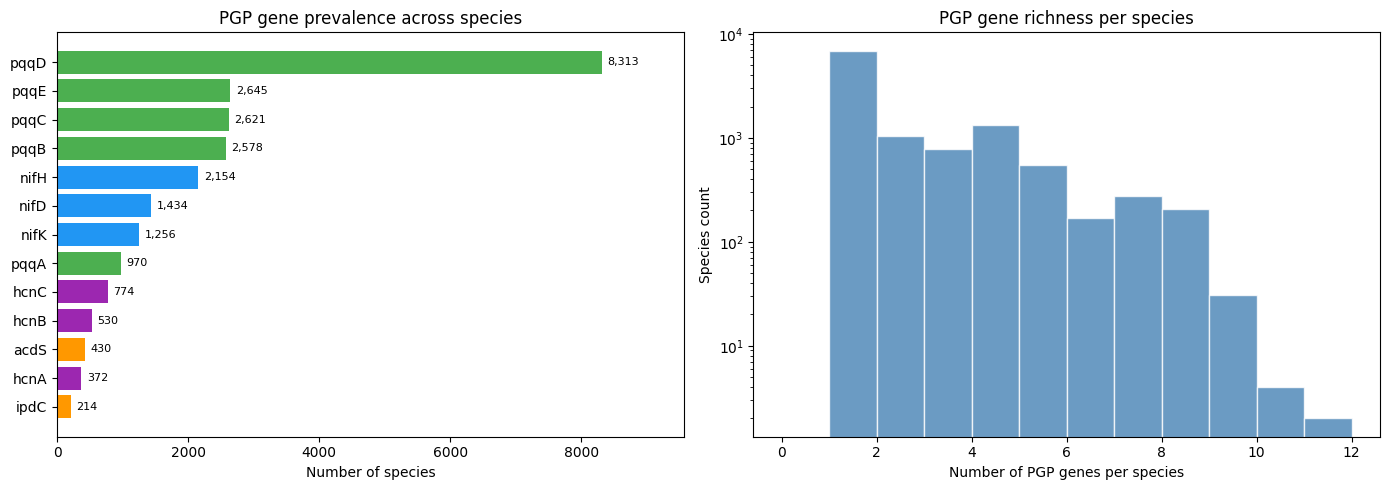

Saved figures/nb01_pgp_prevalence.png


In [11]:
# Summary figure: PGP gene prevalence across species
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-gene species count
ax = axes[0]
gene_counts = {g: species_pgp[f'{g}_present'].sum() for g in PGP_GENES}
gene_df = pd.Series(gene_counts).sort_values(ascending=True)
colors = ['#2196F3' if 'nif' in g else '#4CAF50' if 'pqq' in g
          else '#FF9800' if g in ('ipdC', 'acdS') else '#9C27B0'
          for g in gene_df.index]
ax.barh(gene_df.index, gene_df.values, color=colors)
ax.set_xlabel('Number of species')
ax.set_title('PGP gene prevalence across species')
ax.set_xlim(0, gene_df.max() * 1.15)
for i, (g, n) in enumerate(gene_df.items()):
    ax.text(n + gene_df.max() * 0.01, i, f'{n:,}', va='center', fontsize=8)

# Right: number of PGP genes per species histogram
ax = axes[1]
ax.hist(species_pgp['n_pgp_genes'], bins=range(0, species_pgp['n_pgp_genes'].max() + 2),
        color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of PGP genes per species')
ax.set_ylabel('Species count')
ax.set_title('PGP gene richness per species')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'nb01_pgp_prevalence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/nb01_pgp_prevalence.png')

In [12]:
print('=== NB01 Summary ===')
print(f'PGP clusters extracted: {len(pgp_clusters):,} across {species_pgp["gtdb_species_clade_id"].nunique():,} species')
print(f'Genome environment classified: {classified_frac*100:.1f}% of genomes with isolation_source')
print(f'Species with env label: {len(species_env):,}')
print(f'Pangenome stats: {len(pangenome_stats):,} species')
print(f'GapMind trp: {len(trp_completeness):,} species')
print(f'\nReady for NB02 (co-occurrence), NB03 (env enrichment), NB04 (core/accessory), NB05 (trp-IAA)')

=== NB01 Summary ===
PGP clusters extracted: 32,736 across 11,272 species
Genome environment classified: 100.0% of genomes with isolation_source
Species with env label: 27,690
Pangenome stats: 27,702 species
GapMind trp: 27,690 species

Ready for NB02 (co-occurrence), NB03 (env enrichment), NB04 (core/accessory), NB05 (trp-IAA)
